Insider Threat Detection Models

In [1]:
!pip install pandas numpy scikit-learn matplotlib joblib

1. Import libraries

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

import joblib

2. Loading dataset

In [8]:
activities = pd.read_csv(
    "DBE_Insider_Threat_Dataset.csv",
    low_memory=False
)

print(activities.shape)
activities.head()

(50000, 29)


,timestamp,user_id,location,action,filename,url,to_email,from_email,role,department,...,records_accessed,days_to_exam,insider_threat,work_email,accessed_subject,allowed_exam_access,handled_exam_paper,unauthorised_exam_access,risk_score,risk_level
0,2010-01-02 06:49:00,NGF0157,PC-6056,Logon,NaN,NaN,NaN,NaN,Senior Examination Officer,Results Processing,...,6,112,0,ngf0157@dbe.gov.za,Geography,True,False,False,30,Low
1,2010-01-02 06:50:00,LRR0148,PC-4275,Logon,NaN,NaN,NaN,NaN,Data Capturer,Logistics,...,7,21,0,lrr0148@dbe.gov.za,English FAL,False,False,False,30,Low
2,2010-01-02 06:53:04,LRR0148,PC-4124,Logon,NaN,NaN,NaN,NaN,Data Capturer,Logistics,...,6,8,0,lrr0148@dbe.gov.za,English FAL,False,False,False,30,Low
3,2010-01-02 07:00:00,IRM0931,PC-7188,Logon,NaN,NaN,NaN,NaN,ICT Administrator,Examination Administration,...,7,61,0,irm0931@dbe.gov.za,Business Studies,False,False,False,10,Low
4,2010-01-02 07:00:00,MOH0273,PC-6699,Logon,NaN,NaN,NaN,NaN,Warehouse Officer,Examination Administration,...,7,67,0,moh0273@dbe.gov.za,Physical Sciences,False,False,False,10,Low


3. checking missing values

In [10]:
print(activities.isnull().sum())

timestamp                       0
user_id                         0
location                        0
action                          0
filename                    39483
url                         40000
to_email                    39700
from_email                  39700
role                            0
department                      0
province                        0
subject_permission              0
hour                            0
day                             0
month                           0
weekday                         0
after_hours                     0
weekend                         0
exam_period                     0
records_accessed                0
days_to_exam                    0
insider_threat                  0
work_email                      0
accessed_subject                0
allowed_exam_access             0
handled_exam_paper              0
unauthorised_exam_access        0
risk_score                      0
risk_level                      0
dtype: int64


4. Filling in the missing values

In [12]:
activities["filename"] = activities["filename"].fillna("None")
activities["url"] = activities["url"].fillna("None")
activities["to_email"] = activities["to_email"].fillna("None")
activities["from_email"] = activities["from_email"].fillna("None")

5. Encode Categorical Columns

In [29]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "user_id",
    "location",
    "action",
    "filename",
    "url",
    "to_email",
    "from_email",
    "role",
    "department",
    "province",
    "subject_permission",
    "weekday",
    "work_email",
    "accessed_subject",
    "risk_level"
]

for col in categorical_columns:
    activities[col] = encoder.fit_transform(
        activities[col].astype(str)
    )

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [31]:
X = activities[
[
    "user_id",
    "location",
    "action",
    "filename",
    "url",
    "to_email",
    "from_email",
    "role",
    "department",
    "province",
    "subject_permission",
    "hour",
    "day",
    "month",
    "weekday",
    "after_hours",
    "weekend",
    "exam_period",
    "records_accessed",
    "days_to_exam",
    "work_email",
    "accessed_subject",
    "allowed_exam_access",
    "handled_exam_paper",
    "unauthorised_exam_access",
]
]

print(X.head())

   user_id  location  action  filename  url  to_email  from_email  role  \
0      676       545       4      6221    0      3855         230     5   
1      580       365       4      6221    0      3855         230     1   
2      580       349       4      6221    0      3855         230     1   
3      409       683       4      6221    0      3855         230     2   
4      640       633       4      6221    0      3855         230     6   

   department  province  ...  after_hours  weekend  exam_period  \
0           4         6  ...            1        1            0   
1           1         2  ...            1        1            0   
2           1         2  ...            1        1            0   
3           0         8  ...            0        1            0   
4           0         7  ...            0        1            0   

   records_accessed  days_to_exam  work_email  accessed_subject  \
0                 6           112         707                 4   
1           

6. Select Features

In [33]:
X = activities.drop(
    columns=[
        "timestamp",
        "insider_threat"
    ]
)

y = activities["insider_threat"]

7. Standardize Data

In [25]:
print(X.columns)

Index(['user_id', 'location', 'action', 'filename', 'url', 'to_email',
       'from_email', 'role', 'department', 'province', 'subject_permission',
       'hour', 'day', 'month', 'weekday', 'after_hours', 'weekend',
       'exam_period', 'records_accessed', 'days_to_exam', 'work_email',
       'accessed_subject', 'allowed_exam_access', 'handled_exam_paper',
       'unauthorised_exam_access', 'risk_score', 'risk_level'],
      dtype='object')


In [35]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(50000, 27)


8. Train Isolation Forest

In [38]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

activities["iso_prediction"] = iso.fit_predict(X_scaled)

activities["iso_prediction"] = (
    activities["iso_prediction"] == -1
).astype(int)

print("Isolation Forest trained.")

Isolation Forest trained.


9. Train K-Means

In [41]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

activities["cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means trained.")

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

K-Means trained.


10. Determine Suspicious Cluster 

In [57]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

activities["cluster"] = kmeans.fit_predict(X_scaled)

In [59]:
cluster_sizes = activities["cluster"].value_counts()

print(cluster_sizes)

cluster
1    49664
0      336
Name: count, dtype: int64


In [61]:
suspicious_cluster = cluster_sizes.idxmin()

activities["kmeans_prediction"] = (
    activities["cluster"] == suspicious_cluster
).astype(int)

11. Combine Both Models

In [63]:
activities["final_prediction"] = (
    (activities["iso_prediction"] == 1) |
    (activities["kmeans_prediction"] == 1)
).astype(int)

print("Combined model created.")

Combined model created.


12. Evaluate the Model

In [66]:
accuracy = accuracy_score(
    y,
    activities["final_prediction"]
)

precision = precision_score(
    y,
    activities["final_prediction"]
)

recall = recall_score(
    y,
    activities["final_prediction"]
)

f1 = f1_score(
    y,
    activities["final_prediction"]
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.97662
Precision: 1.0
Recall   : 0.4612903225806452
F1 Score : 0.6313465783664459


13.Confusion Matrix 

In [71]:
cm = confusion_matrix(
    activities["insider_threat"],
    activities["final_prediction"]
)

print(cm)

[[47830     0]
 [ 1169  1001]]


14. Save the Final Model

In [74]:
joblib.dump(
    iso,
    "IsolationForest_Model.pkl"
)

joblib.dump(
    kmeans,
    "KMeans_Model.pkl"
)

joblib.dump(
    scaler,
    "Scaler.pkl"
)

print("Models saved successfully.")

Models saved successfully.


15. Save Results

In [77]:
activities.to_csv(
    "DBE_Model_Results.csv",
    index=False
)

print("Results saved.")

Results saved.


16. Insider Threat Distribution

insider_threat
0    47830
1     2170
Name: count, dtype: int64


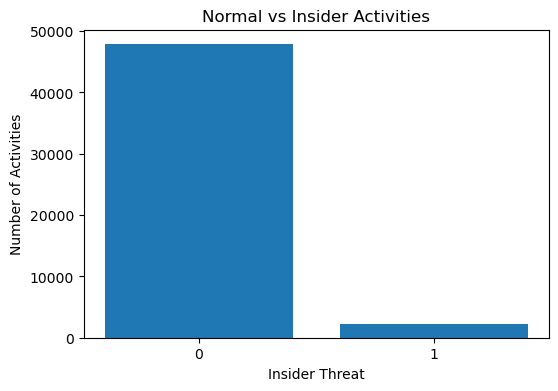

In [80]:
threat_counts = activities["insider_threat"].value_counts()

print(threat_counts)

plt.figure(figsize=(6,4))
plt.bar(
    threat_counts.index.astype(str),
    threat_counts.values
)

plt.title("Normal vs Insider Activities")
plt.xlabel("Insider Threat")
plt.ylabel("Number of Activities")

plt.show()

17. Risk Level Distribution

risk_level
1    47830
0     1182
2      988
Name: count, dtype: int64


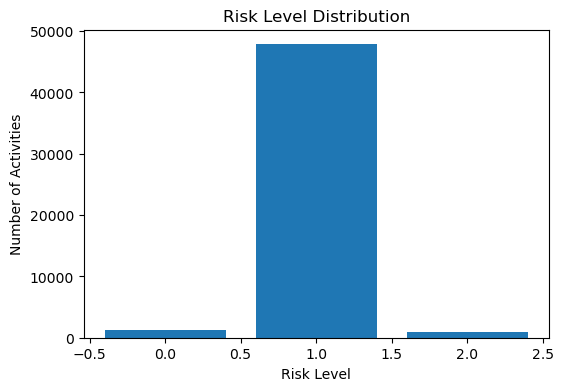

In [84]:
risk_counts = activities["risk_level"].value_counts()

print(risk_counts)

plt.figure(figsize=(6,4))
plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Activities")

plt.show()

18. Employee Actions

action
1    9918
7    9854
4    9829
2    9508
5    9436
3     669
6     454
0     332
Name: count, dtype: int64


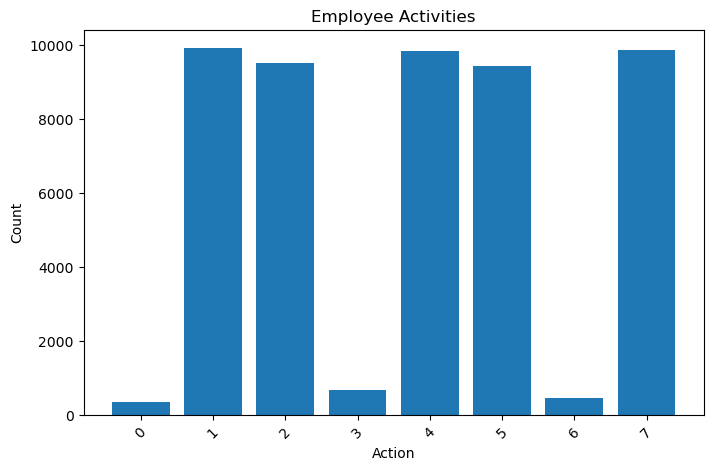

In [90]:
action_counts = activities["action"].value_counts()

print(action_counts)

plt.figure(figsize=(8,5))
plt.bar(
    action_counts.index,
    action_counts.values
)

plt.title("Employee Activities")
plt.xlabel("Action")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

19. Insider Threat Actions

action
3    669
6    454
1    392
0    332
4    323
Name: count, dtype: int64


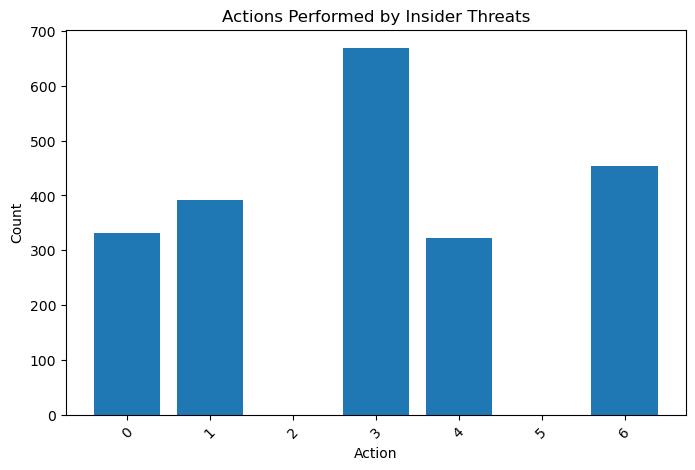

In [93]:
insider_actions = activities[
    activities["insider_threat"] == 1
]["action"].value_counts()

print(insider_actions)

plt.figure(figsize=(8,5))
plt.bar(
    insider_actions.index,
    insider_actions.values
)

plt.title("Actions Performed by Insider Threats")
plt.xlabel("Action")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

20. Roles of Insider Threats

role
1    591
4    552
2    337
5    229
0    212
6    133
3    116
Name: count, dtype: int64


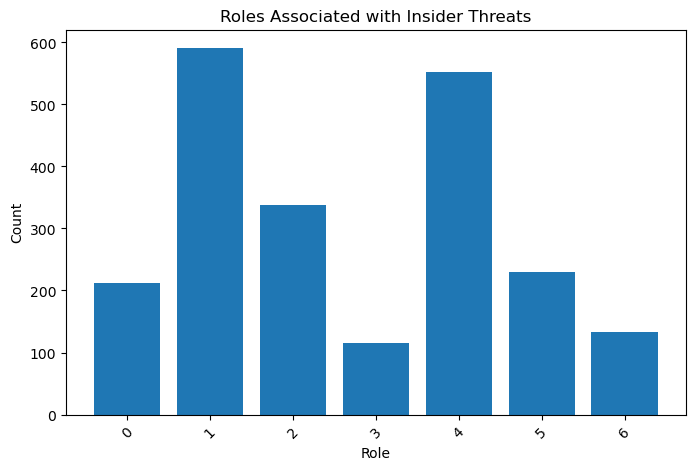

In [96]:
insider_roles = activities[
    activities["insider_threat"] == 1
]["role"].value_counts()

print(insider_roles)

plt.figure(figsize=(8,5))
plt.bar(
    insider_roles.index,
    insider_roles.values
)

plt.title("Roles Associated with Insider Threats")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

21. Model Predictions

final_prediction
0    48999
1     1001
Name: count, dtype: int64


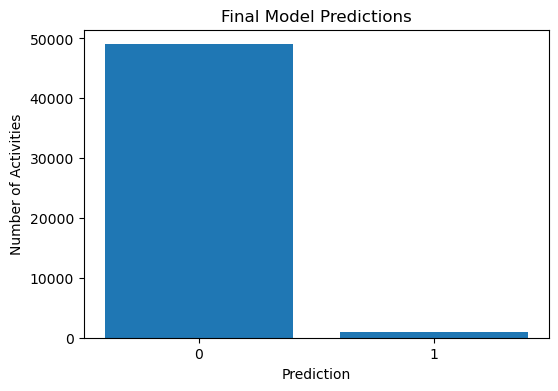

In [99]:
prediction_counts = activities["final_prediction"].value_counts()

print(prediction_counts)

plt.figure(figsize=(6,4))
plt.bar(
    prediction_counts.index.astype(str),
    prediction_counts.values
)

plt.title("Final Model Predictions")
plt.xlabel("Prediction")
plt.ylabel("Number of Activities")

plt.show()

22. Confusion Matrix Heatmap

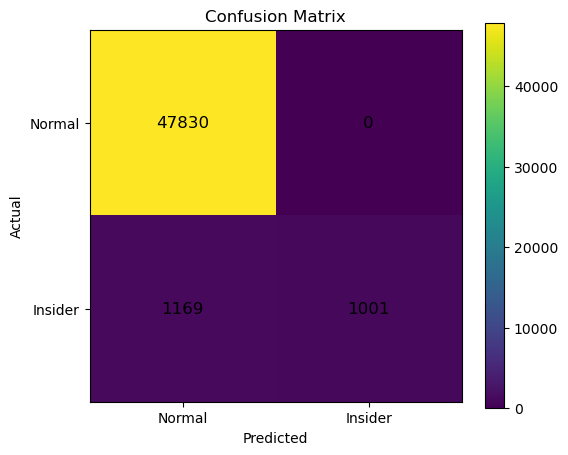

In [102]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Normal","Insider"])
plt.yticks([0,1],["Normal","Insider"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.show()

23. Top 10 Highest Risk Employees

user_id
829    90
974    90
428    90
327    90
176    90
690    90
953    90
450    90
400    90
958    90
Name: risk_score, dtype: int64


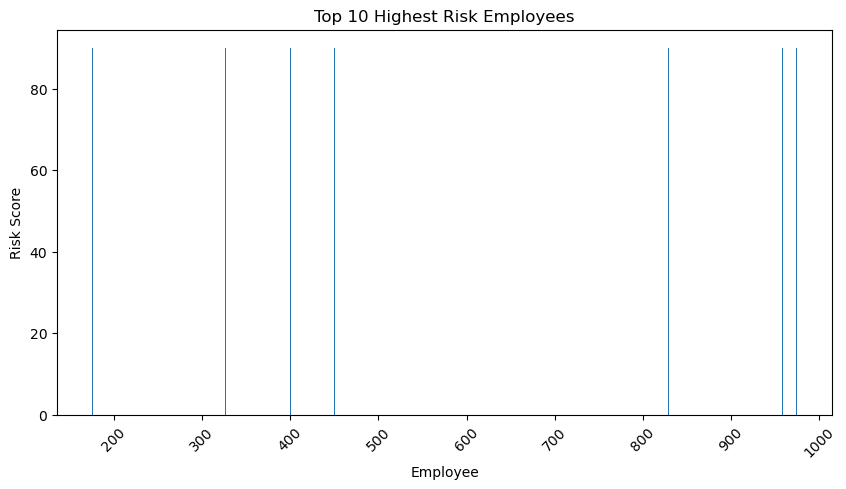

In [105]:
top_users = (
    activities
    .groupby("user_id")["risk_score"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(top_users)

plt.figure(figsize=(10,5))

plt.bar(
    top_users.index,
    top_users.values
)

plt.title("Top 10 Highest Risk Employees")
plt.xlabel("Employee")
plt.ylabel("Risk Score")

plt.xticks(rotation=45)

plt.show()

24. Average Risk Score by Role

role
1    10.131383
4     8.882133
2     7.021137
5     6.045067
0     6.010260
3     4.901286
6     3.959229
Name: risk_score, dtype: float64


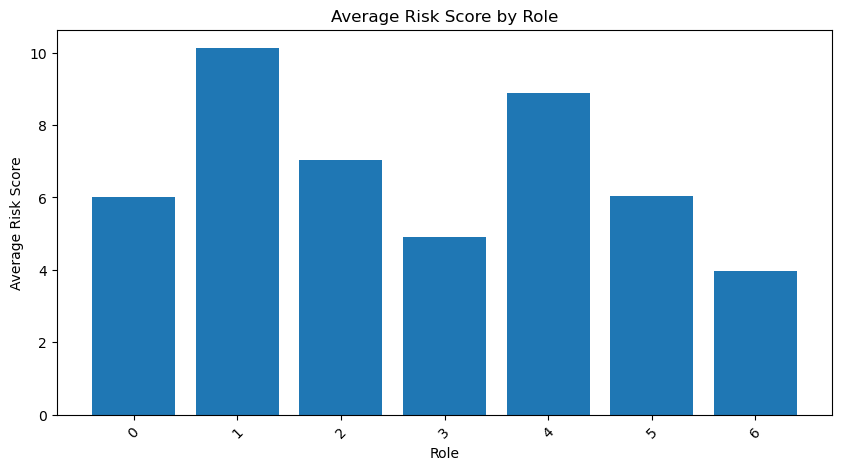

In [108]:
role_risk = (
    activities
    .groupby("role")["risk_score"]
    .mean()
    .sort_values(ascending=False)
)

print(role_risk)

plt.figure(figsize=(10,5))

plt.bar(
    role_risk.index,
    role_risk.values
)

plt.title("Average Risk Score by Role")
plt.xlabel("Role")
plt.ylabel("Average Risk Score")

plt.xticks(rotation=45)

plt.show()

25. Generate Security Alerts

In [111]:
alerts = activities[
    (activities["risk_level"] == "High") &
    (activities["final_prediction"] == 1)
]

print("Number of Security Alerts:", len(alerts))

alerts[
    [
        "timestamp",
        "user_id",
        "role",
        "department",
        "action",
        "risk_score",
        "risk_level"
    ]
].head(20)

Number of Security Alerts: 0


,timestamp,user_id,role,department,action,risk_score,risk_level


26. Top 20 Highest Risk Activities

In [114]:
top_alerts = activities.sort_values(
    by="risk_score",
    ascending=False
).head(20)

top_alerts[
    [
        "timestamp",
        "user_id",
        "role",
        "action",
        "risk_score",
        "risk_level",
        "final_prediction"
    ]
]

,timestamp,user_id,role,action,risk_score,risk_level,final_prediction
3492,2010-01-05 08:04:00,470,2,3,90,0,1
1303,2010-01-04 08:58:00,958,1,3,90,0,1
33417,2010-01-04 10:37:32,327,1,3,90,0,1
695,2010-01-04 07:45:00,400,1,3,90,0,1
696,2010-01-04 07:45:00,416,6,3,90,0,1
11018,2010-01-04 14:14:22,376,2,3,90,0,1
36352,2010-01-04 14:41:49,416,6,3,90,0,1
11746,2010-01-05 10:03:59,958,1,3,90,0,1
10990,2010-01-04 14:01:30,958,1,3,90,0,1
10989,2010-01-04 14:01:15,958,1,3,90,0,1


27.Department Risk Summary 

In [117]:
department_summary = (
    activities
    .groupby("department")
    .agg(
        Total_Activities=("user_id","count"),
        Insider_Threats=("insider_threat","sum"),
        Average_Risk=("risk_score","mean")
    )
    .sort_values(
        by="Average_Risk",
        ascending=False
    )
)

department_summary

,Total_Activities,Insider_Threats,Average_Risk
department,,,
5,10375,624,7.959036
0,10124,499,7.585934
3,8858,491,7.435651
4,6015,178,6.073982
1,7150,158,5.372028
2,7478,220,4.947178


28. Province Risk Summary

In [120]:
province_summary = (
    activities
    .groupby("province")
    .agg(
        Total_Activities=("user_id","count"),
        Insider_Threats=("insider_threat","sum"),
        Average_Risk=("risk_score","mean")
    )
    .sort_values(
        by="Average_Risk",
        ascending=False
    )
)

province_summary

,Total_Activities,Insider_Threats,Average_Risk
province,,,
8,6024,571,10.433267
2,5223,401,9.157572
5,5219,295,8.059973
4,5363,241,6.112251
0,4372,161,6.055581
1,6719,140,5.945081
3,6482,254,5.758254
7,4797,60,4.970815
6,5801,47,4.148423


29. Save Security Alerts

In [123]:
alerts.to_csv(
    "Security_Alerts.csv",
    index=False
)

print("Security alerts saved successfully.")

Security alerts saved successfully.


30. Save Department Report

In [126]:
department_summary.to_csv(
    "Department_Risk_Report.csv"
)

print("Department report saved.")

Department report saved.


31.Save Province Report 

In [129]:
province_summary.to_csv(
    "Province_Risk_Report.csv"
)

print("Province report saved.")

Province report saved.


32. FINAL SUMMARY

In [132]:
print("=" * 60)
print("DBE INSIDER THREAT DETECTION SYSTEM")
print("=" * 60)

print(f"Total Activities          : {len(activities)}")
print(f"Normal Activities         : {(activities['insider_threat']==0).sum()}")
print(f"Insider Threat Activities : {(activities['insider_threat']==1).sum()}")

print()

print(f"Low Risk    : {(activities['risk_level']=='Low').sum()}")
print(f"Medium Risk : {(activities['risk_level']=='Medium').sum()}")
print(f"High Risk   : {(activities['risk_level']=='High').sum()}")

print()

print(f"Isolation Forest Alerts : {activities['iso_prediction'].sum()}")
print(f"KMeans Alerts           : {activities['kmeans_prediction'].sum()}")
print(f"Final Alerts           : {activities['final_prediction'].sum()}")

print()

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("=" * 60)
print("FILES CREATED")
print("=" * 60)

print("✓ DBE_Model_Results.csv")
print("✓ Security_Alerts.csv")
print("✓ Department_Risk_Report.csv")
print("✓ Province_Risk_Report.csv")
print("✓ IsolationForest_Model.pkl")
print("✓ KMeans_Model.pkl")
print("✓ Scaler.pkl")

print("=" * 60)
print("SYSTEM READY FOR FLASK DASHBOARD")
print("=" * 60)

DBE INSIDER THREAT DETECTION SYSTEM
Total Activities          : 50000
Normal Activities         : 47830
Insider Threat Activities : 2170

Low Risk    : 0
Medium Risk : 0
High Risk   : 0

Isolation Forest Alerts : 1000
KMeans Alerts           : 336
Final Alerts           : 1001

Accuracy : 0.9766
Precision: 1.0
Recall   : 0.4613
F1 Score : 0.6313
FILES CREATED
✓ DBE_Model_Results.csv
✓ Security_Alerts.csv
✓ Department_Risk_Report.csv
✓ Province_Risk_Report.csv
✓ IsolationForest_Model.pkl
✓ KMeans_Model.pkl
✓ Scaler.pkl
SYSTEM READY FOR FLASK DASHBOARD


In [134]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Admin
['-1.14-windows.xml', '.anaconda', '.cache', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.dbclient', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.ms-ad', '.spyder-py3', '.VirtualBox', '.virtual_documents', '.vscode', '.vscode-shared', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'code_preprocessing_Cert.ipynb', 'Contacts', 'Cookies', 'CTGAN_MODEL_PROOF.ipynb', 'data', 'DBE_Employee_Activities.csv', 'DBE_Employee_Activities.ipynb', 'DBE_Employee_Behaviour.csv', 'DBE_Employee_Behaviour.ipynb', 'DBE_Insider_Threat_Dataset.csv', 'DBE_Model_Results.csv', 'Department_Risk_Report.csv', 'desktop.ini', 'Documents', 'Downloads', 'exercise sentiment.ipynb', 'Favorites', 'Final_Model.ipynb', 'GAUSSIAN_COPULA_MODEL.ipynb', 'hardshell.ipynb', 'high_risk_customers.csv', 'homework_submission.ipynb', 'Inject_Insider_Threat_Scenarios.ipynb', 'IsolationForest_Model.pkl', 'Jedi', 'KMeans_Model.pkl', 'LAB WORK.ipynb', 'Lin